 Load Data & Season Definitions

In [0]:
# ============================================================
# AG4P-5 | Temporal & Seasonal Analysis
# Platform : Databricks Community Edition
# Input    : /tmp/agro_eda/agro_up_clean.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#c9ccd6',
    'text.color'       : '#c9ccd6',
    'xtick.color'      : '#8b8fa8',
    'ytick.color'      : '#8b8fa8',
    'grid.color'       : '#2a2d3a',
    'grid.alpha'       : 0.5,
})

ACCENT = ['#4e8ef7','#f76e6e','#56d98e','#f7c948','#b48ef7','#f7914e','#4ec9f7','#f74e8e']
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
SAVE   = '/tmp/agro_eda/'

import os
os.makedirs(SAVE, exist_ok=True)

# ── Load ─────────────────────────────────────────────────────
df = pd.read_csv('/Volumes/weather/weather15/up15/agro_up_clean.csv', low_memory=False)
df['date']  = pd.to_datetime(df['date'], errors='coerce')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# ── Season labels ─────────────────────────────────────────────
df['season'] = df['month'].map({
    12:'Winter', 1:'Winter',  2:'Winter',
    3:'Zaid',    4:'Zaid',    5:'Zaid',
    6:'Kharif',  7:'Kharif',  8:'Kharif', 9:'Kharif',
    10:'Rabi',   11:'Rabi'
})

print("=" * 60)
print("AG4P-5 | STEP 1 - Data Loaded")
print("=" * 60)
print("  Rows       :", len(df))
print("  Date range :", str(df['date'].min().date()), "to", str(df['date'].max().date()))

years_list = sorted(df['year'].dropna().astype(int).unique().tolist())
print("  Years      :", years_list)

print("\n  Season distribution:")
print(df['season'].value_counts().to_string())

AG4P-5 | STEP 1 - Data Loaded
  Rows       : 258200
  Date range : 2010-01-01 to 2024-02-20
  Years      : [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

  Season distribution:
season
Kharif    85400
Winter    65700
Zaid      64400
Rabi      42700


AG4P-5 | STEP 2 — Yearly Trend Analysis

  Yearly data coverage:
  Year       Rows  Flag
------------------------------
  2010     18,250  ✅
  2011     18,250  ✅
  2012     18,300  ✅
  2013     18,250  ✅
  2014     18,250  ✅
  2015     18,250  ✅
  2016     18,300  ✅
  2017     18,250  ✅
  2018     18,250  ✅
  2019     18,250  ✅
  2020     18,300  ✅
  2021     18,250  ✅
  2022     18,250  ✅
  2023     18,250  ✅
  2024      2,550  ⚠ sparse


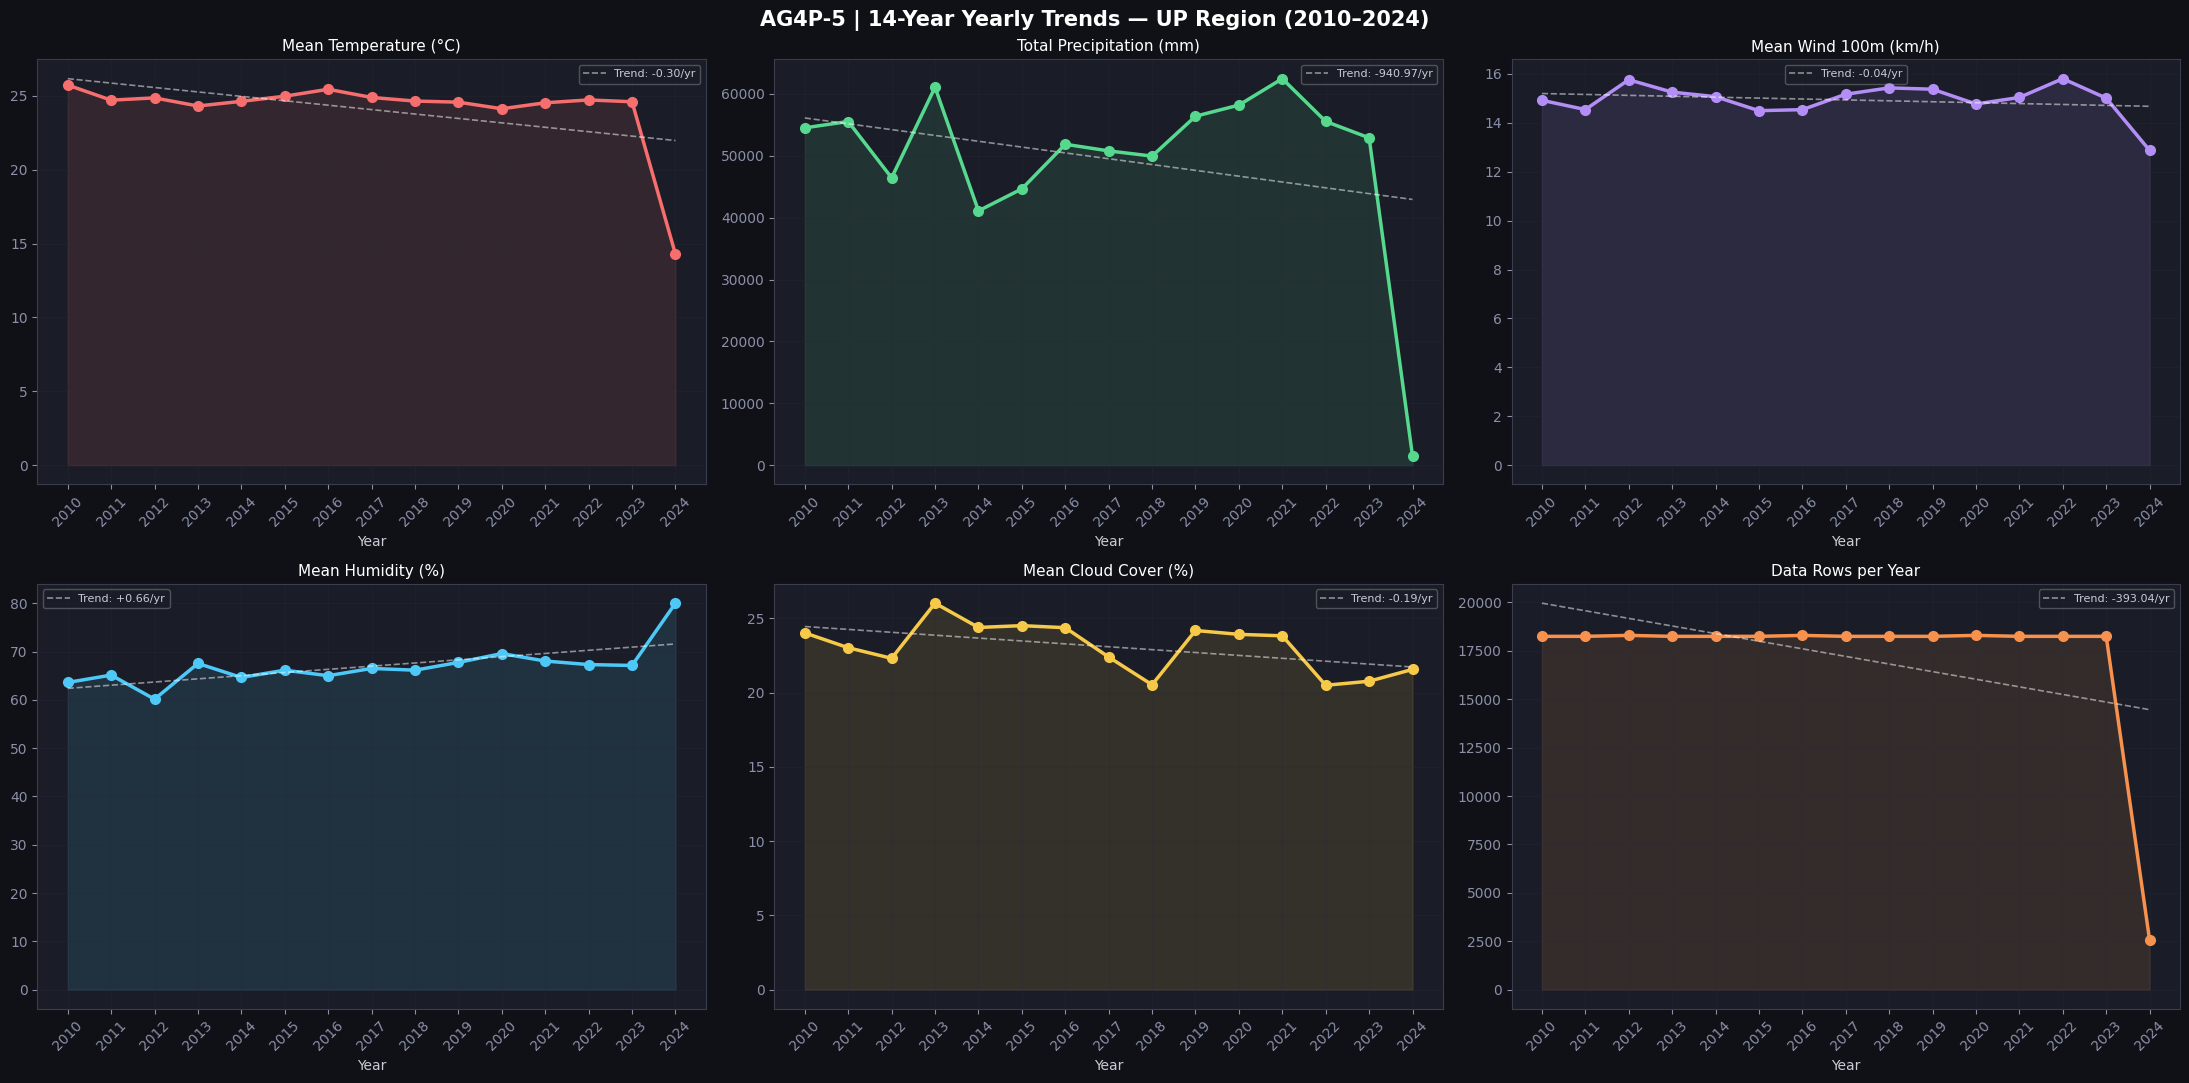

💾 Saved: ag4p5_yearly_trends.png


In [0]:
# ── Yearly Trends (2010–2024) ────────────────────────────────
print("=" * 60)
print("AG4P-5 | STEP 2 — Yearly Trend Analysis")
print("=" * 60)

yearly = df.groupby('year').agg(
    temp_mean    = ('temp_mean',       'mean'),
    precip_total = ('precip_total',    'sum'),
    wind_100m    = ('wind_mean_100m',  'mean'),
    humidity     = ('humidity_mean',   'mean'),
    cloud        = ('cloud_mean',      'mean'),
    row_count    = ('temp_mean',       'count'),
).reset_index()

# Flag years with low data coverage
avg_rows = yearly['row_count'].mean()
yearly['data_flag'] = yearly['row_count'].apply(
    lambda x: '⚠ sparse' if x < avg_rows * 0.7 else '✅'
)

print(f"\n  Yearly data coverage:")
print(f"  {'Year':<6} {'Rows':>8}  {'Flag'}")
print("-" * 30)
for _, row in yearly.iterrows():
    print(f"  {int(row['year']):<6} "
          f"{int(row['row_count']):>8,}  "
          f"{row['data_flag']}")

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
fig.suptitle(
    'AG4P-5 | 14-Year Yearly Trends — UP Region (2010–2024)',
    fontsize=15, fontweight='bold', color='white'
)

pairs = [
    ('temp_mean',    'Mean Temperature (°C)',    '#f76e6e'),
    ('precip_total', 'Total Precipitation (mm)', '#56d98e'),
    ('wind_100m',    'Mean Wind 100m (km/h)',     '#b48ef7'),
    ('humidity',     'Mean Humidity (%)',          '#4ec9f7'),
    ('cloud',        'Mean Cloud Cover (%)',       '#f7c948'),
    ('row_count',    'Data Rows per Year',         '#f7914e'),
]

for ax, (col, label, color) in zip(axes.flat, pairs):
    ax.plot(yearly['year'], yearly[col],
            color=color, lw=2.5, marker='o', markersize=7)
    ax.fill_between(yearly['year'], yearly[col],
                    alpha=0.12, color=color)

    # Trend line
    z = np.polyfit(yearly['year'], yearly[col], 1)
    p = np.poly1d(z)
    ax.plot(yearly['year'], p(yearly['year']),
            '--', color='white', lw=1.2, alpha=0.5,
            label=f'Trend: {z[0]:+.2f}/yr')

    ax.set_title(label, fontsize=11, color='white')
    ax.set_xlabel('Year')
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(yearly['year'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{SAVE}ag4p5_yearly_trends.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("💾 Saved: ag4p5_yearly_trends.png")

AG4P-5 | STEP 3 — Monthly Seasonality


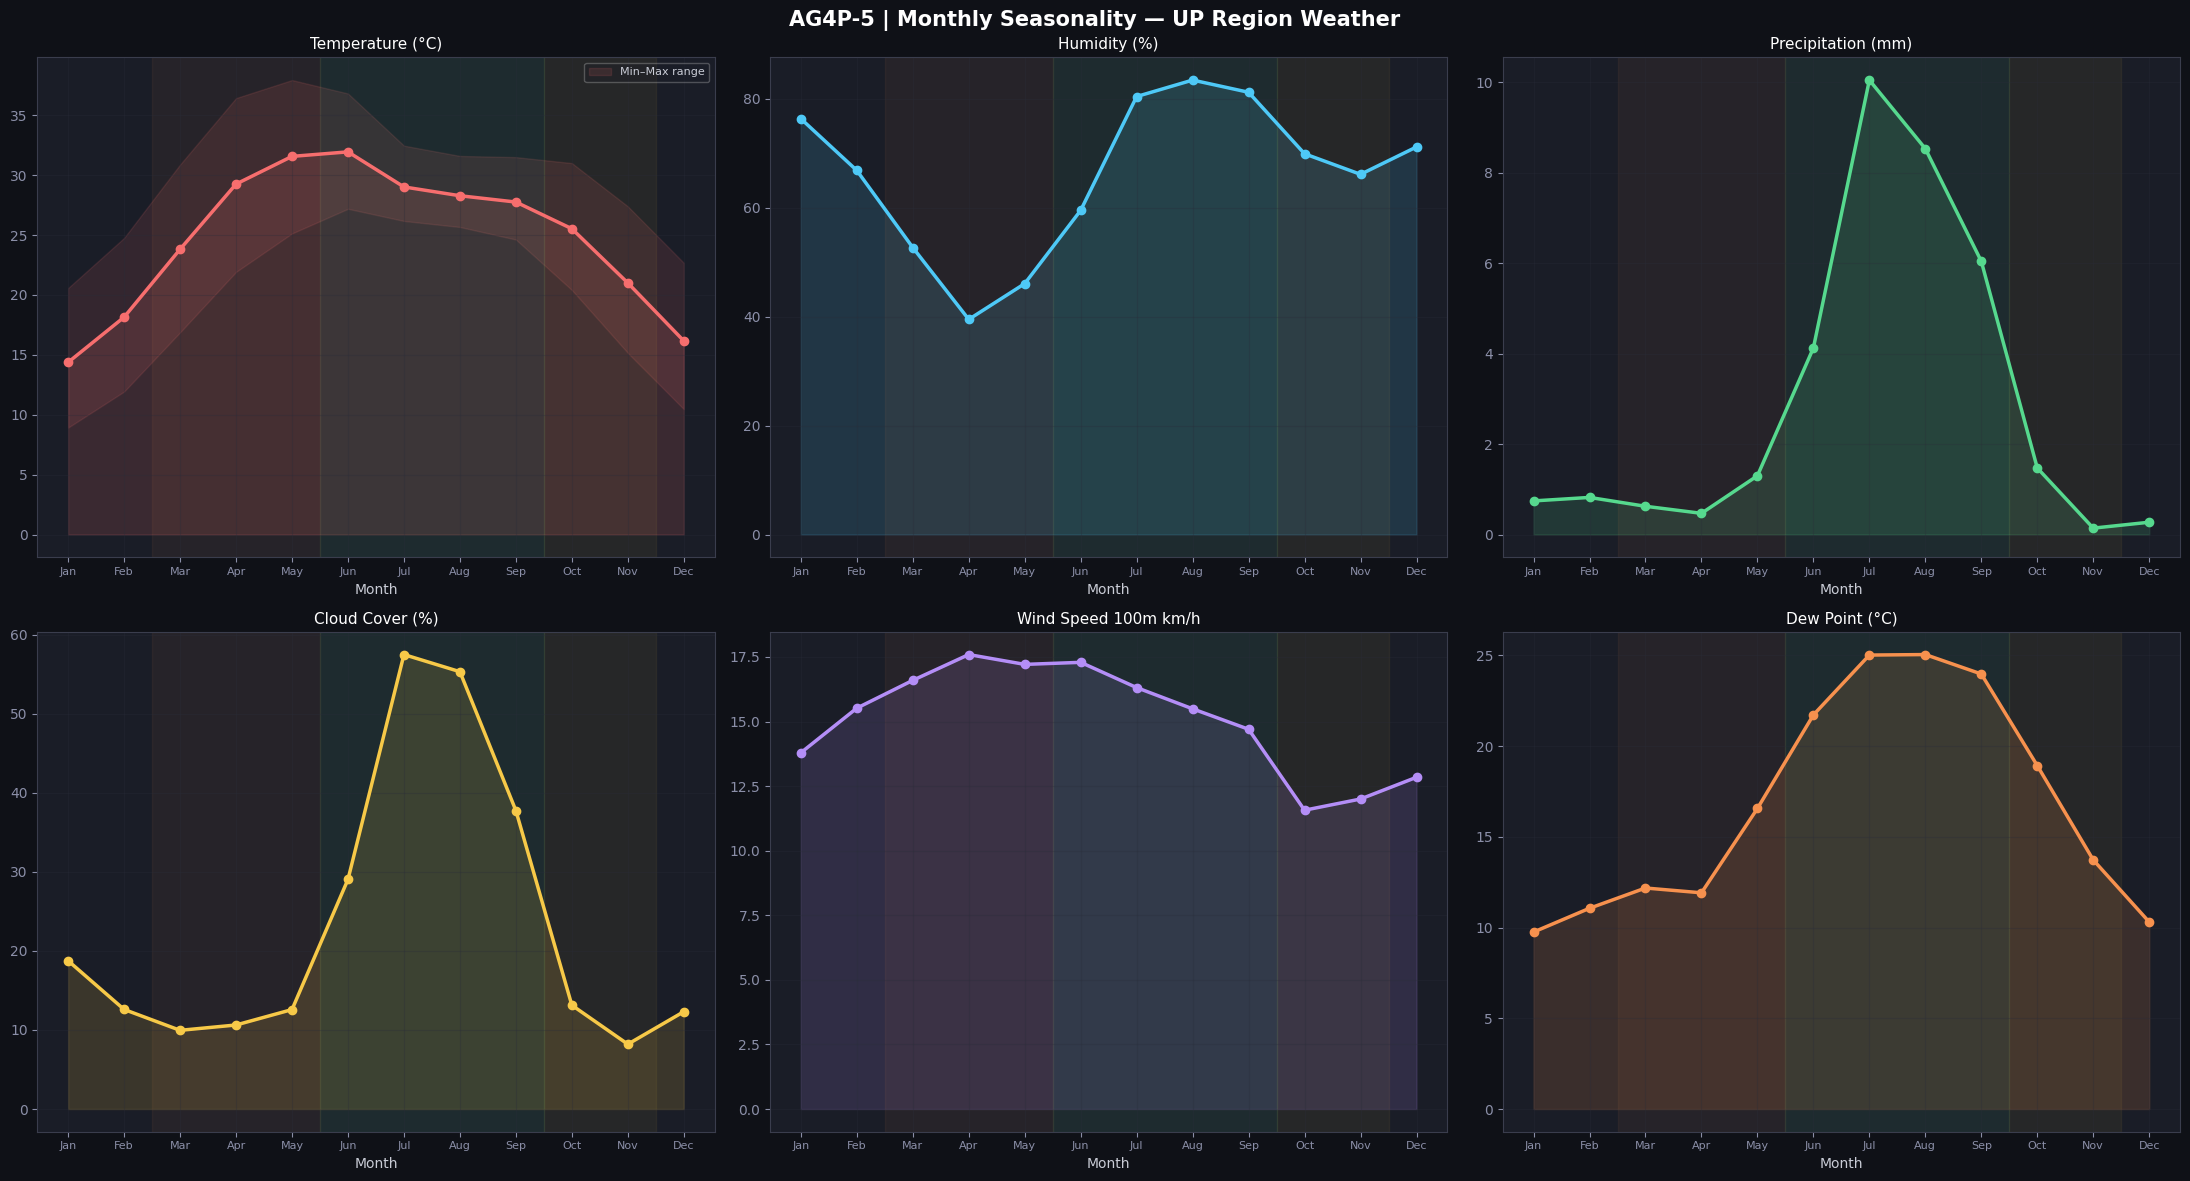

💾 Saved: ag4p5_monthly_seasonality.png

  Peak months in UP data:
  Hottest month  : Jun (31.9°C)
  Wettest month  : Jul (10.04 mm/day avg)
  Windiest month : Apr (17.59 km/h)


In [0]:
# ── Monthly Seasonality ───────────────────────────────────────
print("=" * 60)
print("AG4P-5 | STEP 3 — Monthly Seasonality")
print("=" * 60)

monthly = df.groupby('month').agg(
    temp    = ('temp_mean',      'mean'),
    temp_hi = ('temp_max',       'mean'),
    temp_lo = ('temp_min',       'mean'),
    hum     = ('humidity_mean',  'mean'),
    rain    = ('precip_total',   'mean'),
    cloud   = ('cloud_mean',     'mean'),
    wind    = ('wind_mean_100m', 'mean'),
    dew     = ('dew_mean',       'mean'),
).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle(
    'AG4P-5 | Monthly Seasonality — UP Region Weather',
    fontsize=15, fontweight='bold', color='white'
)

pairs = [
    ('temp',  'Temperature (°C)',    '#f76e6e', True),
    ('hum',   'Humidity (%)',         '#4ec9f7', False),
    ('rain',  'Precipitation (mm)',   '#56d98e', False),
    ('cloud', 'Cloud Cover (%)',      '#f7c948', False),
    ('wind',  'Wind Speed 100m km/h', '#b48ef7', False),
    ('dew',   'Dew Point (°C)',       '#f7914e', False),
]

for ax, (col, label, color, show_band) in zip(axes.flat, pairs):
    ax.plot(monthly['month'], monthly[col],
            color=color, lw=2.5, marker='o', markersize=6)
    ax.fill_between(monthly['month'], monthly[col],
                    alpha=0.15, color=color)

    # Temperature band (max/min)
    if show_band and 'temp_hi' in monthly.columns:
        ax.fill_between(
            monthly['month'],
            monthly['temp_lo'],
            monthly['temp_hi'],
            alpha=0.12, color=color,
            label='Min–Max range'
        )
        ax.legend(fontsize=8, framealpha=0.3)

    # Season shading
    ax.axvspan(5.5,  9.5,  alpha=0.08,
               color='#56d98e', label='Kharif (Jun–Sep)')
    ax.axvspan(9.5,  11.5, alpha=0.06,
               color='#f7c948', label='Rabi start')
    ax.axvspan(2.5,  5.5,  alpha=0.06,
               color='#f7914e', label='Zaid (Mar–May)')

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS, fontsize=8)
    ax.set_title(label, fontsize=11, color='white')
    ax.set_xlabel('Month')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE}ag4p5_monthly_seasonality.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("💾 Saved: ag4p5_monthly_seasonality.png")

# Print peak months
print(f"\n  Peak months in UP data:")
print(f"  Hottest month  : "
      f"{MONTHS[int(monthly.loc[monthly['temp'].idxmax(),'month'])-1]}"
      f" ({monthly['temp'].max():.1f}°C)")
print(f"  Wettest month  : "
      f"{MONTHS[int(monthly.loc[monthly['rain'].idxmax(),'month'])-1]}"
      f" ({monthly['rain'].max():.2f} mm/day avg)")
print(f"  Windiest month : "
      f"{MONTHS[int(monthly.loc[monthly['wind'].idxmax(),'month'])-1]}"
      f" ({monthly['wind'].max():.2f} km/h)")

In [0]:
# ── Pre-Monsoon Signal Window ─────────────────────────────────
print("=" * 60)
print("AG4P-5 | STEP 4 — Pre-Monsoon Signal Window (PS1)")
print("=" * 60)

# This is the window the season onset model will use
# to predict whether Kharif arrives early or late
pre_mon_months = [3, 4, 5]   # Mar–May
monsoon_months = [6, 7, 8, 9]

pre_mon = df[df['month'].isin(pre_mon_months)]
monsoon = df[df['month'].isin(monsoon_months)]

print(f"\n  PRE-MONSOON WINDOW (Mar–May) — PS1 Feature Window")
print(f"  {'Variable':<25} {'Mean':>8}  {'Std':>8}")
print("-" * 45)
for col in ['temp_mean','humidity_mean','cloud_mean',
            'wind_mean_100m','precip_total']:
    if col in pre_mon.columns:
        print(f"  {col:<25} "
              f"{pre_mon[col].mean():>8.2f}  "
              f"{pre_mon[col].std():>8.2f}")

print(f"\n  MONSOON WINDOW (Jun–Sep) — PS1 Target Window")
print(f"  {'Variable':<25} {'Mean':>8}  {'Std':>8}")
print("-" * 45)
for col in ['temp_mean','humidity_mean','cloud_mean',
            'wind_mean_100m','precip_total']:
    if col in monsoon.columns:
        print(f"  {col:<25} "
              f"{monsoon[col].mean():>8.2f}  "
              f"{monsoon[col].std():>8.2f}")

# Year-over-year pre-monsoon anomaly
# This is what PS1 model will use as features
pre_mon_yearly = df[df['month'].isin(pre_mon_months)].groupby(
    'year'
).agg(
    pre_temp  = ('temp_mean',      'mean'),
    pre_rain  = ('precip_total',   'mean'),
    pre_hum   = ('humidity_mean',  'mean'),
    pre_cloud = ('cloud_mean',     'mean'),
).reset_index()

pre_mon_yearly['temp_anomaly'] = (
    pre_mon_yearly['pre_temp'] -
    pre_mon_yearly['pre_temp'].mean()
)

print(f"\n  Pre-monsoon temperature anomaly by year:")
print(f"  (Positive = warmer pre-monsoon than average)")
print(f"  {'Year':<6} {'Pre-mon Temp':>14} {'Anomaly':>10}")
print("-" * 35)
for _, row in pre_mon_yearly.iterrows():
    flag = '🔥' if row['temp_anomaly'] > 1 else \
           '❄' if row['temp_anomaly'] < -1 else '  '
    print(f"  {int(row['year']):<6} "
          f"{row['pre_temp']:>14.2f}°C "
          f"{row['temp_anomaly']:>+10.2f}  {flag}")

AG4P-5 | STEP 4 — Pre-Monsoon Signal Window (PS1)

  PRE-MONSOON WINDOW (Mar–May) — PS1 Feature Window
  Variable                      Mean       Std
---------------------------------------------
  temp_mean                    28.20      4.39
  humidity_mean                46.14     16.43
  cloud_mean                   11.06     13.27
  wind_mean_100m               17.13      5.28
  precip_total                  0.80      3.89

  MONSOON WINDOW (Jun–Sep) — PS1 Target Window
  Variable                      Mean       Std
---------------------------------------------
  temp_mean                    29.24      2.58
  humidity_mean                76.22     14.96
  cloud_mean                   45.11     27.03
  wind_mean_100m               15.95      6.56
  precip_total                  7.22     12.08

  Pre-monsoon temperature anomaly by year:
  (Positive = warmer pre-monsoon than average)
  Year     Pre-mon Temp    Anomaly
-----------------------------------
  2010            30.66°C      

AG4P-5 | STEP 5 — Crop Season Threshold Validation

  Kharif (Jun–Sep)
    Avg temp          : 29.24°C
    In threshold range: 98.3%  ✅ VALID
    Avg daily rain    : 7.218 mm
    Avg humidity      : 76.2%

  Rabi (Oct–Feb)
    Avg temp          : 18.97°C
    In threshold range: 86.9%  ✅ VALID
    Avg daily rain    : 0.692 mm
    Avg humidity      : 70.2%

  Zaid (Mar–May)
    Avg temp          : 28.20°C
    In threshold range: 76.5%  ✅ VALID
    Avg daily rain    : 0.800 mm
    Avg humidity      : 46.1%


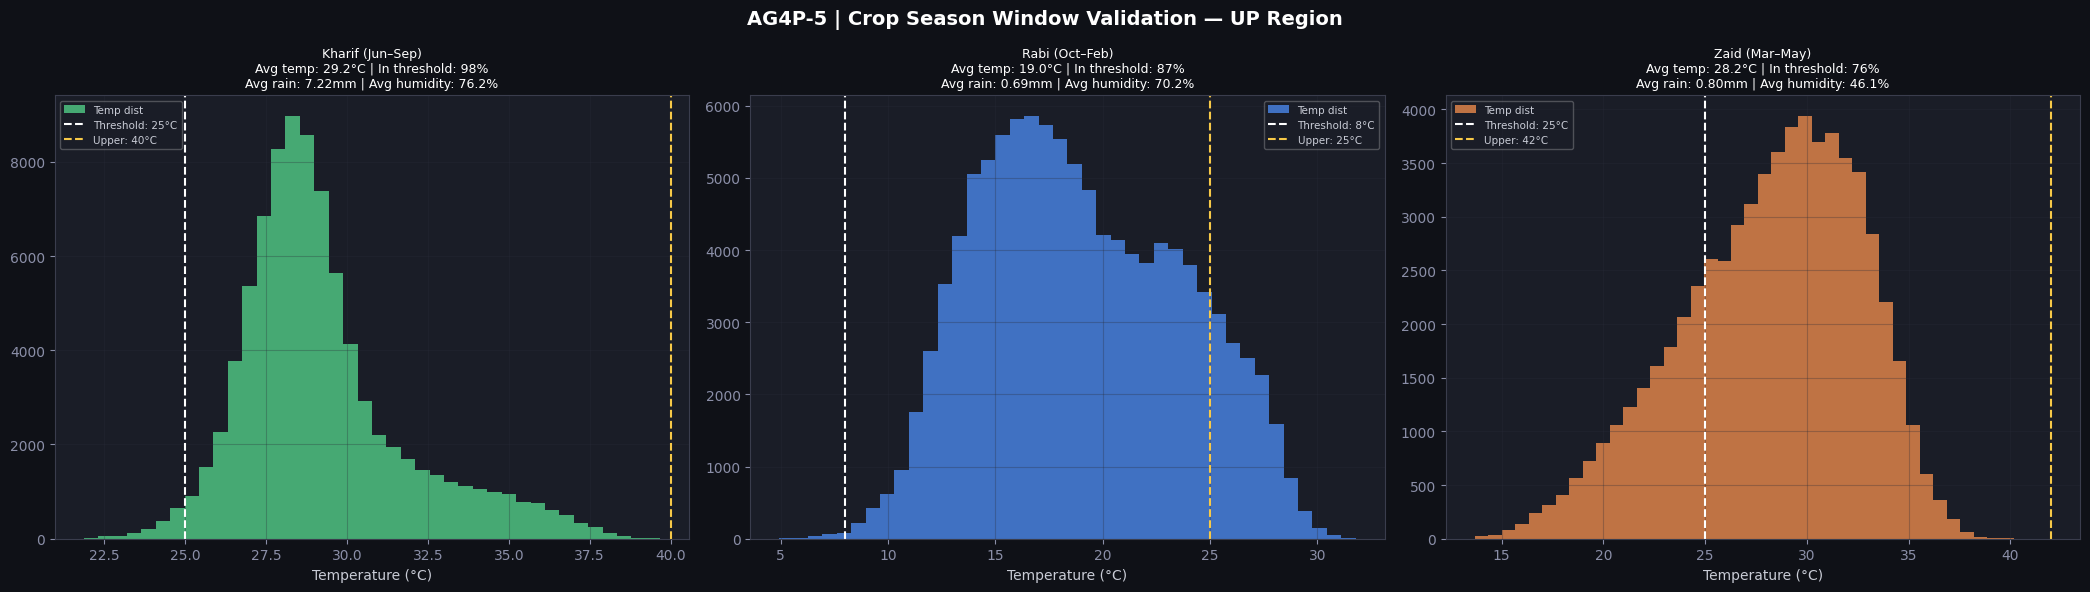


💾 Saved: ag4p5_season_validation.png


In [0]:
# ── Crop Season Window Validation ────────────────────────────
print("=" * 60)
print("AG4P-5 | STEP 5 — Crop Season Threshold Validation")
print("=" * 60)

seasons_def = {
    'Kharif (Jun–Sep)' : {
        'months'    : [6, 7, 8, 9],
        'temp_range': (25, 40),
        'rain_min'  : 2.0,
        'color'     : '#56d98e'
    },
    'Rabi (Oct–Feb)'   : {
        'months'    : [10, 11, 12, 1, 2],
        'temp_range': (8, 25),
        'rain_min'  : 0.0,
        'color'     : '#4e8ef7'
    },
    'Zaid (Mar–May)'   : {
        'months'    : [3, 4, 5],
        'temp_range': (25, 42),
        'rain_min'  : 0.0,
        'color'     : '#f7914e'
    },
}

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(
    'AG4P-5 | Crop Season Window Validation — UP Region',
    fontsize=14, fontweight='bold', color='white'
)

for ax, (season_name, cfg) in zip(axes, seasons_def.items()):
    sub = df[df['month'].isin(cfg['months'])]

    t_mean = sub['temp_mean'].mean() \
        if 'temp_mean' in sub.columns else 0
    r_mean = sub['precip_total'].mean() \
        if 'precip_total' in sub.columns else 0
    h_mean = sub['humidity_mean'].mean() \
        if 'humidity_mean' in sub.columns else 0

    # Temperature distribution
    if 'temp_mean' in sub.columns:
        ax.hist(sub['temp_mean'].dropna(), bins=40,
                color=cfg['color'], alpha=0.75,
                edgecolor='none', label='Temp dist')
        ax.axvline(cfg['temp_range'][0],
                   color='white', lw=1.5, ls='--',
                   label=f"Threshold: {cfg['temp_range'][0]}°C")
        ax.axvline(cfg['temp_range'][1],
                   color='#f7c948', lw=1.5, ls='--',
                   label=f"Upper: {cfg['temp_range'][1]}°C")

    in_range = (
        (sub['temp_mean'] >= cfg['temp_range'][0]) &
        (sub['temp_mean'] <= cfg['temp_range'][1])
    ).mean() * 100 if 'temp_mean' in sub.columns else 0

    ax.set_title(
        f"{season_name}\n"
        f"Avg temp: {t_mean:.1f}°C | "
        f"In threshold: {in_range:.0f}%\n"
        f"Avg rain: {r_mean:.2f}mm | "
        f"Avg humidity: {h_mean:.1f}%",
        fontsize=9, color='white'
    )
    ax.set_xlabel('Temperature (°C)')
    ax.legend(fontsize=7.5, framealpha=0.3)
    ax.grid(True, alpha=0.3)

    # Validation result
    status = '✅ VALID' if in_range > 60 else '⚠ WEAK SIGNAL'
    print(f"\n  {season_name}")
    print(f"    Avg temp          : {t_mean:.2f}°C")
    print(f"    In threshold range: {in_range:.1f}%  {status}")
    print(f"    Avg daily rain    : {r_mean:.3f} mm")
    print(f"    Avg humidity      : {h_mean:.1f}%")

plt.tight_layout()
plt.savefig(f'{SAVE}ag4p5_season_validation.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("\n💾 Saved: ag4p5_season_validation.png")

AG4P-5 | STEP 6 — Season-wise Weather Comparison


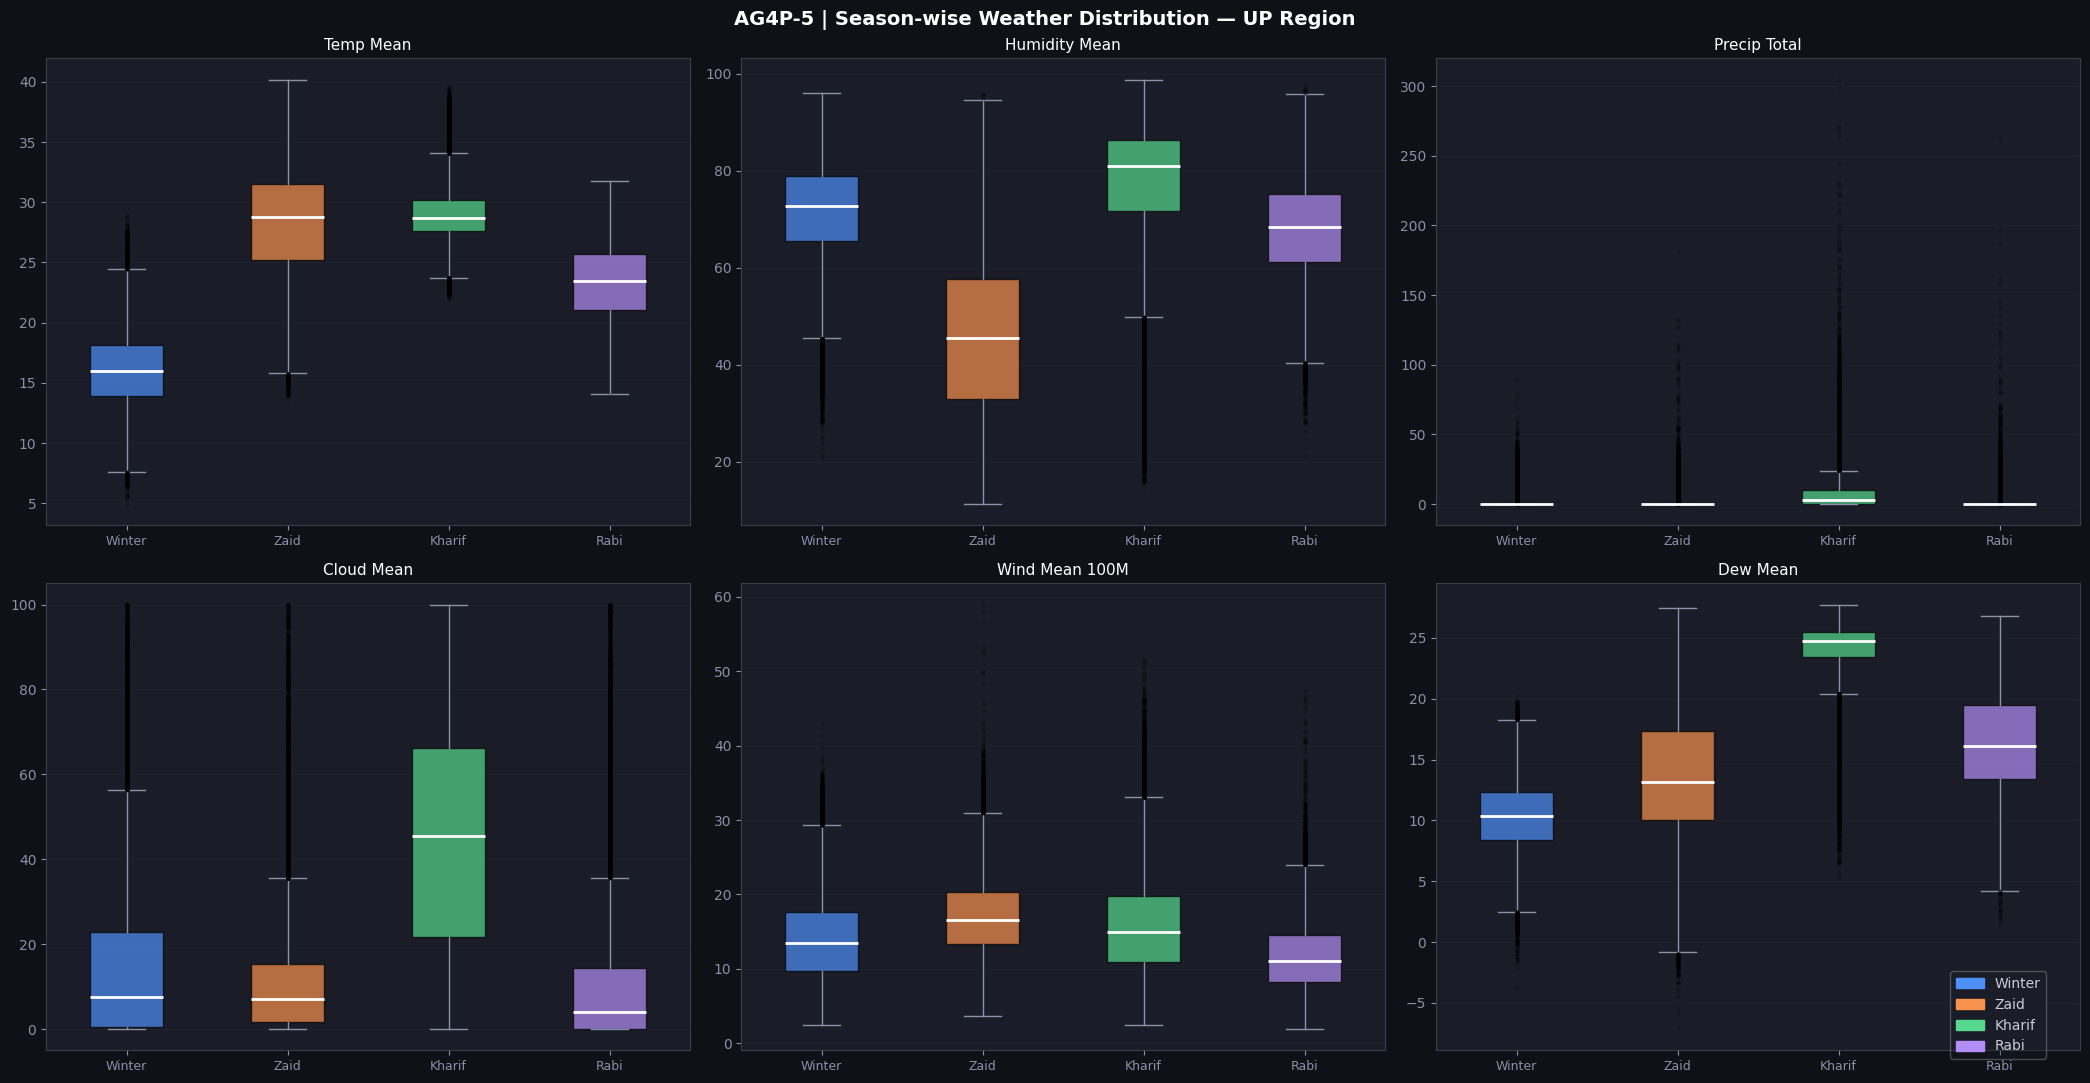

💾 Saved: ag4p5_season_comparison.png


In [0]:
# ── Season-wise Variable Comparison ─────────────────────────
# (Daily data — no hourly, so compare across seasons instead)
print("=" * 60)
print("AG4P-5 | STEP 6 — Season-wise Weather Comparison")
print("=" * 60)

season_order  = ['Winter','Zaid','Kharif','Rabi']
season_colors = ['#4e8ef7','#f7914e','#56d98e','#b48ef7']

plot_vars = [c for c in ['temp_mean','humidity_mean',
                           'precip_total','cloud_mean',
                           'wind_mean_100m','dew_mean']
             if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(21, 11))
fig.suptitle(
    'AG4P-5 | Season-wise Weather Distribution — UP Region',
    fontsize=14, fontweight='bold', color='white'
)

for ax, col in zip(axes.flat, plot_vars):
    season_data = [
        df[df['season'] == s][col].dropna()
        for s in season_order
    ]

    bp = ax.boxplot(
        season_data,
        patch_artist = True,
        notch        = False,
        medianprops  = dict(color='white', lw=2),
        whiskerprops = dict(color='#8b8fa8'),
        capprops     = dict(color='#8b8fa8'),
        flierprops   = dict(marker='o', alpha=0.2,
                            markersize=2)
    )

    for patch, color in zip(bp['boxes'], season_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for flier, color in zip(bp['fliers'], season_colors):
        flier.set_color(color)

    ax.set_xticklabels(season_order, fontsize=9)
    ax.set_title(col.replace('_', ' ').title(),
                 fontsize=11, color='white')
    ax.grid(True, alpha=0.3, axis='y')

# Hide unused
for ax in axes.flat[len(plot_vars):]:
    ax.set_visible(False)

# Legend
patches = [
    mpatches.Patch(color=c, label=s)
    for s, c in zip(season_order, season_colors)
]
fig.legend(handles=patches, loc='lower right',
           fontsize=10, framealpha=0.3,
           bbox_to_anchor=(0.98, 0.02))

plt.tight_layout()
plt.savefig(f'{SAVE}ag4p5_season_comparison.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("💾 Saved: ag4p5_season_comparison.png")

AG4P-5 | STEP 7 — Year-over-Year Monsoon Signal


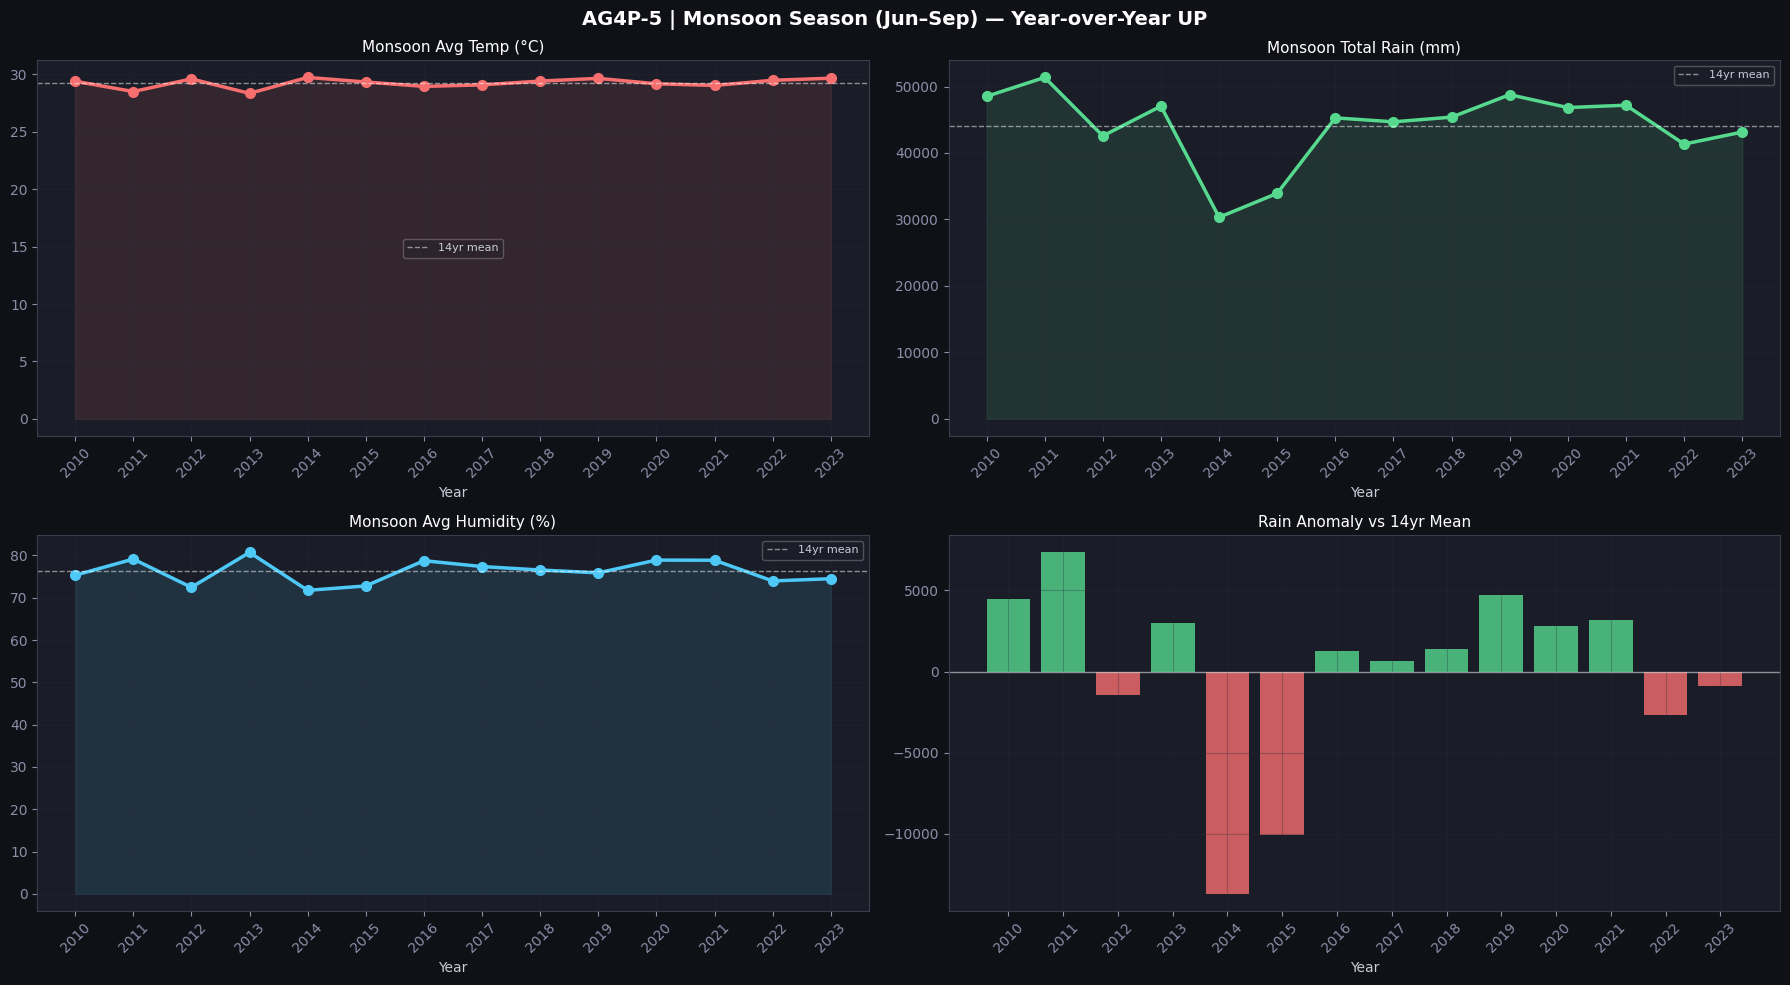

💾 Saved: ag4p5_monsoon_yearly.png

  Monsoon rain variability across 14 years:
  Best monsoon year  : 2011 (51372 mm)
  Worst monsoon year : 2014 (30330 mm)
  Variability (std)  : 5733.6 mm

  ✅ Year-to-year variability confirmed — PS1 model has signal to learn from


In [0]:
# ── Year-over-Year Monsoon Onset Signal ──────────────────────
print("=" * 60)
print("AG4P-5 | STEP 7 — Year-over-Year Monsoon Signal")
print("=" * 60)

# For each year — what does the monsoon window look like?
# This is direct evidence for PS1 model feasibility
monsoon_yearly = df[df['month'].isin([6,7,8,9])].groupby(
    'year'
).agg(
    mon_temp  = ('temp_mean',     'mean'),
    mon_rain  = ('precip_total',  'sum'),
    mon_hum   = ('humidity_mean', 'mean'),
    mon_cloud = ('cloud_mean',    'mean'),
).reset_index()

monsoon_yearly['rain_anomaly'] = (
    monsoon_yearly['mon_rain'] -
    monsoon_yearly['mon_rain'].mean()
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle(
    'AG4P-5 | Monsoon Season (Jun–Sep) — Year-over-Year UP',
    fontsize=14, fontweight='bold', color='white'
)

pairs = [
    ('mon_temp',     'Monsoon Avg Temp (°C)',     '#f76e6e'),
    ('mon_rain',     'Monsoon Total Rain (mm)',    '#56d98e'),
    ('mon_hum',      'Monsoon Avg Humidity (%)',   '#4ec9f7'),
    ('rain_anomaly', 'Rain Anomaly vs 14yr Mean',  '#f7c948'),
]

for ax, (col, label, color) in zip(axes.flat, pairs):
    if col == 'rain_anomaly':
        # Bar chart for anomaly — positive/negative clear
        colors_bar = [
            '#56d98e' if v >= 0 else '#f76e6e'
            for v in monsoon_yearly[col]
        ]
        ax.bar(monsoon_yearly['year'],
               monsoon_yearly[col],
               color=colors_bar, alpha=0.8,
               edgecolor='none')
        ax.axhline(0, color='white', lw=1, alpha=0.5)
    else:
        ax.plot(monsoon_yearly['year'],
                monsoon_yearly[col],
                color=color, lw=2.5,
                marker='o', markersize=7)
        ax.fill_between(monsoon_yearly['year'],
                        monsoon_yearly[col],
                        alpha=0.12, color=color)
        # Mean line
        ax.axhline(monsoon_yearly[col].mean(),
                   color='white', lw=1, ls='--',
                   alpha=0.5, label='14yr mean')
        ax.legend(fontsize=8, framealpha=0.3)

    ax.set_title(label, fontsize=11, color='white')
    ax.set_xlabel('Year')
    ax.set_xticks(monsoon_yearly['year'])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE}ag4p5_monsoon_yearly.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("💾 Saved: ag4p5_monsoon_yearly.png")

print(f"\n  Monsoon rain variability across 14 years:")
print(f"  Best monsoon year  : "
      f"{int(monsoon_yearly.loc[monsoon_yearly['mon_rain'].idxmax(),'year'])}"
      f" ({monsoon_yearly['mon_rain'].max():.0f} mm)")
print(f"  Worst monsoon year : "
      f"{int(monsoon_yearly.loc[monsoon_yearly['mon_rain'].idxmin(),'year'])}"
      f" ({monsoon_yearly['mon_rain'].min():.0f} mm)")
print(f"  Variability (std)  : "
      f"{monsoon_yearly['mon_rain'].std():.1f} mm")
print(f"\n  ✅ Year-to-year variability confirmed —"
      f" PS1 model has signal to learn from")